# Neural Network exercise on Diabetes dataset

I will try and develop a model that can predict diabetes on a person. I will perform data cleaning for building, running, training and testing the model.

In diabetes prediction problems, health analysts will collect information such as age, exercise routine, junk food-eating habits, alcohol consumption, and smoking habit characteristics.

These features will be used to predict whether the patient will suffer from diabetes (label = 1).

Based on TensorFlow model, develop, train and test a model to predict diabetes.

## Importing data and libraries

In [20]:
import pandas as pd
import numpy as np

In [21]:
import os
os.getcwd()

'/Users/simonmino/Documents/TBS/B3/Data Science/Big Data Modelling Techniques/Session 4 - 21'

In [22]:
df = pd.read_csv('diabetes.csv')
df.head()

,smoking,glucose,bp,alcohol,insulin,exercise,junkfood,age,label
0,6,148.0,72.0,35.0,0.0,33.6,0.627,50.0,1.0
1,1,85.0,66.0,29.0,0.0,26.6,0.351,31.0,0.0
2,8,183.0,64.0,0.0,0.0,23.3,0.672,32.0,1.0
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0.0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1.0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 770 entries, 0 to 769
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   smoking   770 non-null    int64  
 1   glucose   769 non-null    float64
 2   bp        769 non-null    float64
 3   alcohol   769 non-null    float64
 4   insulin   769 non-null    float64
 5   exercise  769 non-null    float64
 6   junkfood  769 non-null    float64
 7   age       769 non-null    float64
 8   label     769 non-null    float64
dtypes: float64(8), int64(1)
memory usage: 54.3 KB


In [24]:
df.describe()

,smoking,glucose,bp,alcohol,insulin,exercise,junkfood,age,label
count,770.000000,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000
mean,3.848052,120.570871,68.921977,20.472042,79.273082,31.904161,0.471107,33.161248,0.348505
std,3.366094,33.188469,20.001280,16.041598,116.090362,8.251711,0.331800,11.958261,0.476807
min,0.000000,-128.000000,-72.000000,-29.000000,-325.000000,-36.000000,-0.120000,-28.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,29.000000,32.000000,0.371000,29.000000,0.000000
75%,6.000000,140.000000,80.000000,32.000000,127.000000,36.600000,0.626000,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Data Cleaning

Removing of dirty values and dropping NA values

In [25]:
df.isnull().sum()

smoking     0
glucose     1
bp          1
alcohol     1
insulin     1
exercise    1
junkfood    1
age         1
label       1
dtype: int64

In [26]:
df.dropna(inplace=True)
df.isnull().sum()

smoking     0
glucose     0
bp          0
alcohol     0
insulin     0
exercise    0
junkfood    0
age         0
label       0
dtype: int64

In [27]:
df.shape

(769, 9)

## Data visualization

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

Text(0, 0.5, 'Variable Name')

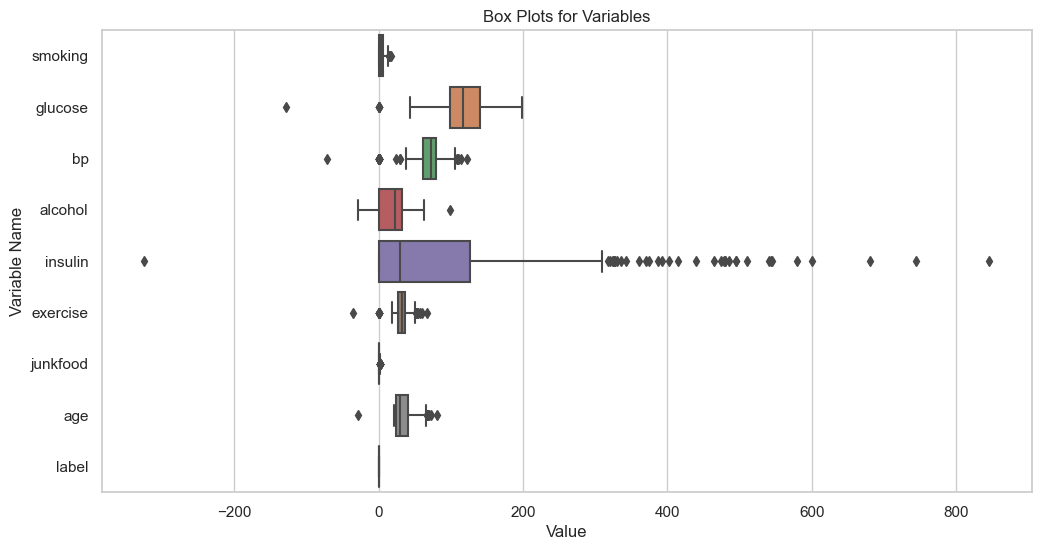

In [29]:
sns.set(style="whitegrid")

# Create a box plot for each variable in the DataFrame
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, orient="h")

plt.title("Box Plots for Variables")
plt.xlabel("Value")
plt.ylabel("Variable Name")

### Outliers

In [30]:
# Insulin has many outliers, so we must remove them.

Q1 = df['insulin'].quantile(0.25)
Q3 = df['insulin'].quantile(0.75)

IQR = Q3 - Q1
is_outlier = (df['insulin'] < (Q1 - 1.5 * IQR)) | (df['insulin'] > (Q3 + 1.5 * IQR))

df = df[~is_outlier]

In [33]:
# Blood pressure has also some outliers.

Q1 = df['bp'].quantile(0.25)
Q3 = df['bp'].quantile(0.75)

IQR = Q3 - Q1
is_outlier = (df['bp'] < (Q1 - 1.5 * IQR)) | (df['bp'] > (Q3 + 1.5 * IQR))

df = df[~is_outlier]

In [34]:
df

,smoking,glucose,bp,alcohol,insulin,exercise,junkfood,age,label
0,6,148.0,72.0,35.0,0.0,33.6,0.627,50.0,1.0
1,1,85.0,66.0,29.0,0.0,26.6,0.351,31.0,0.0
2,8,183.0,64.0,0.0,0.0,23.3,0.672,32.0,1.0
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0.0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1.0
...,...,...,...,...,...,...,...,...,...
765,10,101.0,76.0,48.0,180.0,32.9,0.171,63.0,0.0
766,2,122.0,70.0,27.0,0.0,36.8,0.340,27.0,0.0
767,5,121.0,72.0,23.0,112.0,26.2,0.245,30.0,0.0
768,1,126.0,60.0,0.0,0.0,30.1,0.349,47.0,1.0


## Target variable

In [35]:
y = df['label'].astype('Int64')
y

0      1
1      0
2      1
3      0
4      1
      ..
765    0
766    0
767    0
768    1
769    0
Name: label, Length: 688, dtype: Int64

# Separating the dataset

In [37]:
y = df['label'].astype('Int64')
y = y.to_numpy()  ### y as an array
y

array([1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,

In [40]:
X = df.loc[:, ~df.columns.isin(['label'])]   # take the whole list except the "label"

# Building the Model

In [47]:
import tensorflow as tf

In [48]:
## function

def build_neural_network(input_dim, num_layers, num_neurons_per_layer, output_dim):
    model = tf.keras.Sequential()

    # Input layer
    model.add(tf.keras.layers.InputLayer(input_shape=(input_dim,)))
    
    # Hidden layers
    for _ in range(num_layers):
        model.add(tf.keras.layers.Dense(num_neurons_per_layer, activation='sigmoid'))
        
    # The variable _ is commonly used as a placeholder for a loop variable, 
    # when you don't actually need to use the value of the variable within the loop
    
    # Output layer
    model.add(tf.keras.layers.Dense(output_dim, activation='sigmoid'))
    
    return model

In [49]:
# Set the number of predictors, outcome, layers, and neurons per layer
num_predictors = 8           # number of columns
num_outcome = 2              # results that are between 1 and 2
num_layers = 2               # two layers
num_neurons_per_layer = 16   # 16 neurons per layer

# Build the neural network architecture
model = build_neural_network(num_predictors, num_layers, num_neurons_per_layer, num_outcome)

# Print a summary of the model architecture
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 16)                144       
                                                                 
 dense_1 (Dense)             (None, 16)                272       
                                                                 
 dense_2 (Dense)             (None, 2)                 34        
                                                                 
Total params: 450
Trainable params: 450
Non-trainable params: 0
_________________________________________________________________


# Running the Model

In [50]:
# loading data
predictors = X
# Assume your categorical outcome is represented as 0 or 1
outcomes = y

# Convert categorical outcomes to one-hot encoding
from keras.utils import to_categorical
categorical_outcomes = to_categorical(outcomes, num_classes=2)  ### 2 classes or factors

In [51]:
len(categorical_outcomes)

688

In [52]:
# partition data into training and testing set 
from sklearn.model_selection import train_test_split
feature_train,feature_test, outcome_train, outcome_test = train_test_split(X, categorical_outcomes, test_size=0.1, 
                                                                           random_state=1)

In [53]:
len(feature_train)

619

In [54]:
# Compile the model
MM=model.compile(optimizer='SGD', loss='binary_crossentropy', metrics=['accuracy'])

# SGD = Stochastic Gradient Descent
# For bi-class classification tasks, you might use 'binary_crossentropy' 
# The metrics parameter monitors a performance. 'accuracy', precision, recall, or F1-score can be used
# Train the model
batch_size = 100 #### more or less 6 times 100 


# Training the Model

In [55]:
num_epochs = 100
# an epoch is completed when the model has seen and been trained on all batches

model.fit(feature_train, outcome_train, epochs=num_epochs, batch_size=batch_size)

Epoch 1/100
7/7 [==============================] - 0s 934us/step - loss: 0.6779 - accuracy: 0.6656
Epoch 2/100
7/7 [==============================] - 0s 752us/step - loss: 0.6737 - accuracy: 0.6656
Epoch 3/100
7/7 [==============================] - 0s 732us/step - loss: 0.6700 - accuracy: 0.6656
Epoch 4/100
7/7 [==============================] - 0s 673us/step - loss: 0.6669 - accuracy: 0.6656
Epoch 5/100
7/7 [==============================] - 0s 666us/step - loss: 0.6641 - accuracy: 0.6656
Epoch 6/100
1/7 [===>..........................] - ETA: 0s - loss: 0.6597 - accuracy: 0.6800

2024-01-29 11:56:27.856482: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


7/7 [==============================] - 0s 573us/step - loss: 0.6610 - accuracy: 0.6656
Epoch 7/100
7/7 [==============================] - 0s 484us/step - loss: 0.6589 - accuracy: 0.6656
Epoch 8/100
7/7 [==============================] - 0s 656us/step - loss: 0.6568 - accuracy: 0.6656
Epoch 9/100
7/7 [==============================] - 0s 622us/step - loss: 0.6546 - accuracy: 0.6656
Epoch 10/100
7/7 [==============================] - 0s 535us/step - loss: 0.6530 - accuracy: 0.6656
Epoch 11/100
7/7 [==============================] - 0s 586us/step - loss: 0.6512 - accuracy: 0.6656
Epoch 12/100
7/7 [==============================] - 0s 595us/step - loss: 0.6496 - accuracy: 0.6656
Epoch 13/100
7/7 [==============================] - 0s 645us/step - loss: 0.6483 - accuracy: 0.6656
Epoch 14/100
7/7 [==============================] - 0s 533us/step - loss: 0.6472 - accuracy: 0.6656
Epoch 15/100
7/7 [==============================] - 0s 649us/step - loss: 0.6464 - accuracy: 0.6656
Epoch 16/100
7/7

7/7 [==============================] - 0s 599us/step - loss: 0.6334 - accuracy: 0.6656
Epoch 89/100
7/7 [==============================] - 0s 514us/step - loss: 0.6334 - accuracy: 0.6656
Epoch 90/100
7/7 [==============================] - 0s 560us/step - loss: 0.6334 - accuracy: 0.6656
Epoch 91/100
7/7 [==============================] - 0s 621us/step - loss: 0.6334 - accuracy: 0.6656
Epoch 92/100
7/7 [==============================] - 0s 565us/step - loss: 0.6333 - accuracy: 0.6656
Epoch 93/100
7/7 [==============================] - 0s 587us/step - loss: 0.6333 - accuracy: 0.6656
Epoch 94/100
7/7 [==============================] - 0s 547us/step - loss: 0.6332 - accuracy: 0.6656
Epoch 95/100
7/7 [==============================] - 0s 561us/step - loss: 0.6332 - accuracy: 0.6656
Epoch 96/100
7/7 [==============================] - 0s 524us/step - loss: 0.6332 - accuracy: 0.6656
Epoch 97/100
7/7 [==============================] - 0s 519us/step - loss: 0.6332 - accuracy: 0.6656
Epoch 98/100


# Prediction

In [56]:
len(feature_test)

69

In [57]:
outcome_test

array([[1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.

In [58]:
predictions = model.predict(feature_test)

3/3 [==============================] - 0s 676us/step


In [59]:
print(predictions[1])

[0.63613015 0.338136  ]


In [60]:
np.argmax(predictions[1])  #This prediction is 65% sure it is not diabetes.

0

In [61]:
predicted_classes = np.argmax(predictions, axis=1)

In [62]:
predicted_classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0])

# Test the Model

In [63]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [64]:
# Calculate evaluation metrics
precision = precision_score(np.argmax(outcome_test, axis=1), predicted_classes, average='weighted', zero_division=1)
recall = recall_score(np.argmax(outcome_test, axis=1), predicted_classes, average='weighted', zero_division=1)
f1 = f1_score(np.argmax(outcome_test, axis=1), predicted_classes, average='weighted', zero_division=1)
accuracy = accuracy_score(np.argmax(outcome_test, axis=1), predicted_classes)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Accuracy:", accuracy)

# The np.argmax function is used to convert the one-hot encoded outcomes
# and predicted classes back to their original form before passing them to the metrics functions.

# Setting zero_division=1 will make sure that precision, recall, and F1 score
# are not set to 0 when there are no predicted samples for a class. 
# This parameter allows you to control the behavior of these metrics when no samples are predicted for a particular class.

Precision: 0.7941608905692082
Recall: 0.7101449275362319
F1 Score: 0.5897813804961926
Accuracy: 0.7101449275362319


Precision measures the proportion of positive predictions made by the model that are in reality correct. It is 0.79, so 76% of positive predictions are correct.

Recall shows if the model is able to acuuratley identify all positive values in a dataset. It is high for our model, so it is a good model.

F1 score is a ranges between 0-1. The higher the value the better the model performance. It tells us if recall and precision are balanced. This model has a medium F1 score, but it is not low either.

Accuracy measures the proportion of correct instances out of all instances in the dataset. For our model we got 0.62, high value in this case. Our model predicts correctly 61% of all instances.
Our model performs good when identifying people who have diabetes or not, in general.